In [1]:
import numpy as np

# Spettri
s = np.load('../data/10k/X_spectra_10k.npy')#, mmap_mode='r')
# Corrispondenti campi magnetici
B = np.load('../data/10k/Y_B_field_10k.npy')
# Asse x (frequenze)
f = np.arange(2500, 3300)
x_axis = range(2500, 3300)
# Labels
posizioni_fit_tot = np.loadtxt('../data/10k/posizioni_fit_otto_pseudo_voigt.txt', delimiter=',')

N_spettri, N_punti = s.shape[0], s.shape[1]

Provo ad addestrare un LSTM a prevedere le posizioni dei picchi a partire dagli spettri


### Importazioni

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input, Dropout, Bidirectional
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.layers import GaussianNoise

### 1. CARICAMENTO E PREPARAZIONE DEI DATI

In [3]:
# Supponiamo che 's' sia il tuo array di 10k spettri (es. shape: (10000, N_punti))
# e 'posizioni_fit_tot' sia il tuo array di labels (shape: (10000, 8))
# Sostituisci queste due righe con il caricamento effettivo dei tuoi dati se sono su file
# X_raw = np.load('spettri.npy') 
# y_raw = np.loadtxt('../data/10k/posizioni_fit_otto_pseudo_voigt.txt', delimiter=',')

X_raw = s  # Shape attesa: (10000, N_punti)
y = np.sort(posizioni_fit_tot, axis=1)  # Shape attesa: (10000, 8)

# Normalizzazione degli input (Spettri) e degli output (Posizioni)
# Usiamo MinMaxScaler per portare tutto nel range [0, 1], ideale per le reti neurali
scaler_X = MinMaxScaler()

# Per scalare X, dobbiamo prima "appiattirlo", scalarlo e poi rimetterlo a posto
X_scaled = scaler_X.fit_transform(X_raw.T).T 
y_scaled = (y - 2500) / 800 # Le labels così sono da 0 (2.5 GHz) a 1 (3.3 GHz) 

# Reshape di X per la LSTM: (campioni, timestep, features)
# features = 1 perché ad ogni "passo" (frequenza) hai un solo valore (l'intensità)
N_campioni, N_punti = X_scaled.shape
X_lstm = X_scaled.reshape((N_campioni, N_punti, 1))

# HACK: separo in train/test tenendo traccia degli indici
indici_originali = np.arange(len(X_lstm))

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_lstm, 
    y_scaled, 
    indici_originali, # <-- Aggiunto qui
    test_size=0.20, 
    random_state=42
)

print(f"Shape X_train: {X_train.shape}")
print(f"Shape y_train: {y_train.shape}")
print(f"Shape X_test: {X_test.shape}")

Shape X_train: (8000, 800, 1)
Shape y_train: (8000, 8)
Shape X_test: (2000, 800, 1)


### 2. COSTRUZIONE DELL'ARCHITETTURA LSTM


In [4]:
modello = Sequential()

# Input layer
modello.add(Input(shape=(N_punti, 1)))

# SUCCESSIVAMENTE: AGGIUNGERE RUMORE BIANCO (GAUSSIANO)
# Regola lo stddev in base all'ampiezza tipica del rumore nei tuoi spettri normalizzati.
modello.add(GaussianNoise(stddev=0.01))

# Primo layer LSTM con Regolarizzazione L2 sui pesi
modello.add(Bidirectional(LSTM(64, activation='tanh', return_sequences=True, 
                 kernel_regularizer=l2(0.001), recurrent_dropout=0.2)))

# Dropout al 20% dopo il primo strato
modello.add(Dropout(0.2))

# Secondo layer LSTM
modello.add(Bidirectional(LSTM(32, activation='tanh', return_sequences=False,
                 kernel_regularizer=l2(0.001), recurrent_dropout=0.2)))

# Dropout al 20% prima dell'output
modello.add(Dropout(0.2))

# Layer di Output
modello.add(Dense(8))

modello.compile(optimizer='adam', loss='mse', metrics=['mae'])
modello.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gaussian_noise (GaussianNoise)  │ (None, 800, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 800, 128)       │        33,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 800, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,528 (295.03 KB)

 Trainable params: 75,528 (295.03 KB)

 Non-trainable params: 0 (0.00 B)

### 3. ADDESTRAMENTO

quasi 2 ore!

In [5]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Se per 5 epoche non migliora, dimezza il learning rate (factor=0.5)
riduci_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

# EarlyStopping ferma l'addestramento se il modello smette di migliorare sul validation set,
# evitando l'overfitting e facendoti risparmiare tempo.
early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

# Fit del modello
history = modello.fit(
    X_train, 
    y_train,
    epochs=60,             # Numero massimo di iterazioni (verrà fermato prima dall'EarlyStopping se converge)
    batch_size=128,          # Quanti spettri processare insieme (aumentalo a 128 o 256 per maggiore velocità)
    validation_data=(X_test, y_test),
    callbacks=[early_stop, riduci_lr],
    
    verbose=1
)

Epoch 1/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - loss: 0.2012 - mae: 0.1237 - val_loss: 0.1037 - val_mae: 0.0410 - learning_rate: 0.0010
Epoch 2/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - loss: 0.0743 - mae: 0.0737 - val_loss: 0.0426 - val_mae: 0.0397 - learning_rate: 0.0010
Epoch 3/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 102s 2s/step - loss: 0.0351 - mae: 0.0667 - val_loss: 0.0217 - val_mae: 0.0387 - learning_rate: 0.0010
Epoch 4/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 100s 2s/step - loss: 0.0207 - mae: 0.0621 - val_loss: 0.0136 - val_mae: 0.0397 - learning_rate: 0.0010
Epoch 5/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 102s 2s/step - loss: 0.0143 - mae: 0.0591 - val_loss: 0.0094 - val_mae: 0.0385 - learning_rate: 0.0010
Epoch 6/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 106s 2s/step - loss: 0.0108 - mae: 0.0570 - val_loss: 0.0070 - val_mae: 0.0380 - learning_rate: 0.0010
Epoch 7/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step - loss: 0.0086 - mae: 0.0551 - val_loss: 0.0056 - val_mae: 0.0379 - learning_rate: 0.0010
Epoch 8/60
63/6

### 4. INFERENZA E RICONVERSIONE

In [6]:
# Testiamo il modello facendo una predizione sul set di test
predizioni_scaled = modello.predict(X_test)

# Le predizioni sono tra 0 e 1, dobbiamo riportarle alle frequenze reali (es. 2870)
predizioni_mhz = predizioni_scaled * 800 + 2500

y_test_mhz = y_test * 800 + 2500

# Stampiamo il primo spettro di test per confronto
print("\nConfronto sul primo spettro di test (Valori reali vs Predetti):")
print(f"Reali:   {np.round(y_test_mhz[0], 2)}")
print(f"Predetti:{np.round(predizioni_mhz[0], 2)}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 173ms/step

Confronto sul primo spettro di test (Valori reali vs Predetti):
Reali:   [2732.09 2795.32 2820.37 2848.98 2861.54 2935.62 2956.78 3007.79]
Predetti:[2757.94 2796.25 2824.35 2848.12 2892.6  2925.57 2948.75 2980.41]


In [7]:
idx_test[0]

6252

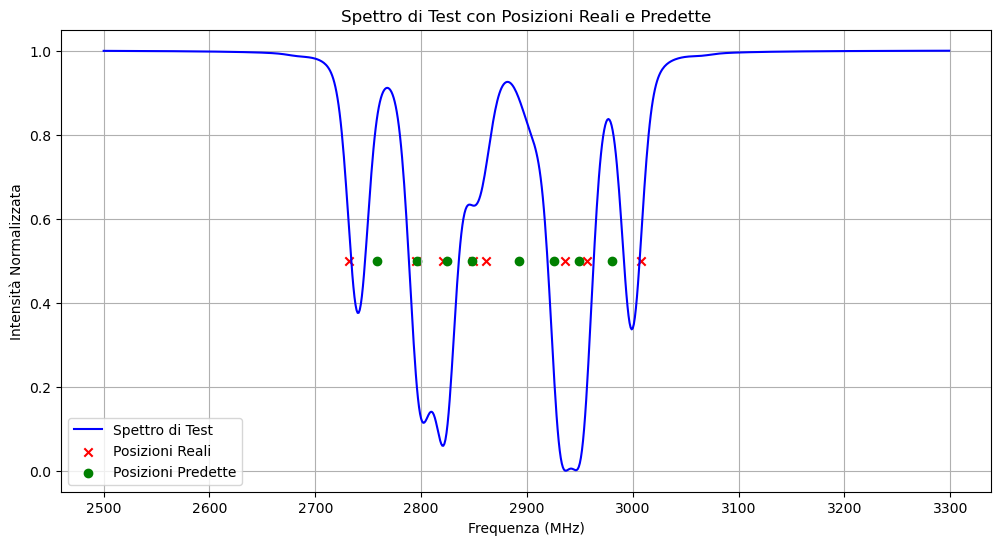

In [8]:
# plotto il primo spettro di test con le posizioni reali e predette
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(x_axis, X_test[0], label='Spettro di Test', color='blue') # X_raw[idx_test[0]]
plt.scatter(y_test_mhz[0], [0.5]*8, label='Posizioni Reali', color='red', marker='x')
plt.scatter(predizioni_mhz[0], [0.5]*8, label='Posizioni Predette', color='green', marker='o')
plt.title('Spettro di Test con Posizioni Reali e Predette')
plt.xlabel('Frequenza (MHz)')
plt.ylabel('Intensità Normalizzata')
plt.legend()
plt.grid()
plt.show()

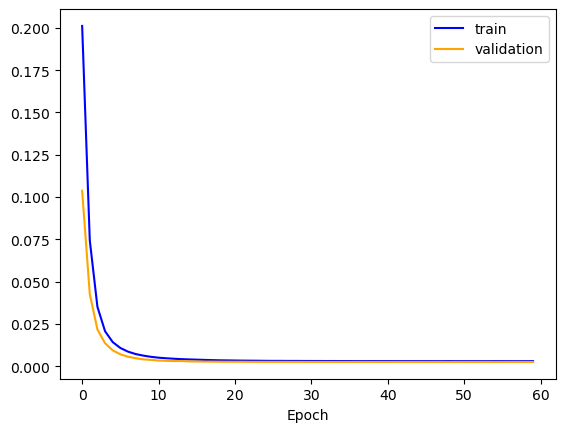

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [9]:
# plot loss
plt.plot(history.history['loss'], color='blue', label='train')
plt.plot(history.history['val_loss'], color='orange', label='validation')
plt.xlabel('Epoch')
plt.legend()
plt.show()
plt.clf()

# save plot to file
plt.show()
plt.clf()

In [ ]:
# 1. Calcoliamo l'errore assoluto per ogni singolo picco (Shape: N_test x 8)
errori_assoluti = np.abs(y_test_mhz - predizioni_mhz)

# Errore medio per ogni "indice" di picco (dal picco 1 al picco 8)
errore_medio_per_picco = np.mean(errori_assoluti, axis=0)

print("Errore Medio per singolo picco (MHz):")
for i, err in enumerate(errore_medio_per_picco):
    print(f"Picco {i+1}: {err:.2f} MHz")

# 2. Analisi: L'errore dipende da quanto sono vicini i picchi?
# Calcoliamo la distanza tra ogni picco e il suo vicino di destra (solo per i primi 7 picchi)
distanze_adiacenti = np.diff(y_test_mhz, axis=1) # Shape: N_test x 7

# Prendiamo gli errori corrispondenti a questi primi 7 picchi
errori_primi_7 = errori_assoluti[:, :-1]

# Facciamo un plot a dispersione (Scatter)
plt.figure(figsize=(10, 6))
plt.scatter(distanze_adiacenti.flatten(), errori_primi_7.flatten(), alpha=0.1, s=5, c='red')
plt.title("Impatto della sovrapposizione: Errore vs Distanza dal picco adiacente")
plt.xlabel("Distanza tra due picchi adiacenti (MHz)")
plt.ylabel("Errore di predizione assoluto (MHz)")
plt.axhline(3.0, color='black', linestyle='--', label='Target (3 MHz)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()